In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_features=2, n_samples=1000, centers=3)

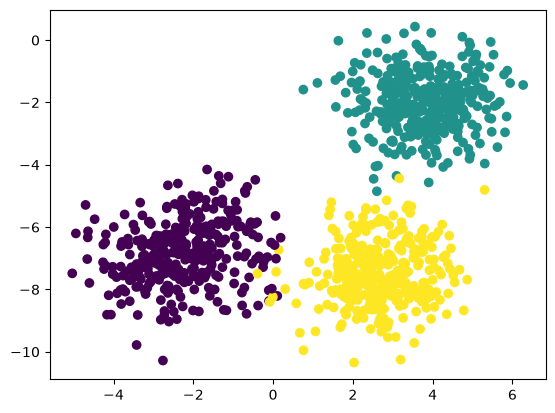

In [3]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [4]:
# Train test split
X_train, X_test, y_train, y_test = skl.model_selection.train_test_split(
    X, y, test_size=0.33, random_state=42
)

In [5]:
# Standard Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [6]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Elbow method to select k value
from sklearn.cluster import KMeans

wcss = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.update({k: kmeans.inertia_})

In [8]:
wcss

{1: 1339.9999999999995,
 2: 519.5678857849982,
 3: 176.93310614838475,
 4: 151.4903739036223,
 5: 129.73400834164852,
 6: 117.91520008423555,
 7: 102.10210018931306,
 8: 87.49629763082567,
 9: 76.33981521346786,
 10: 72.1604639558014}

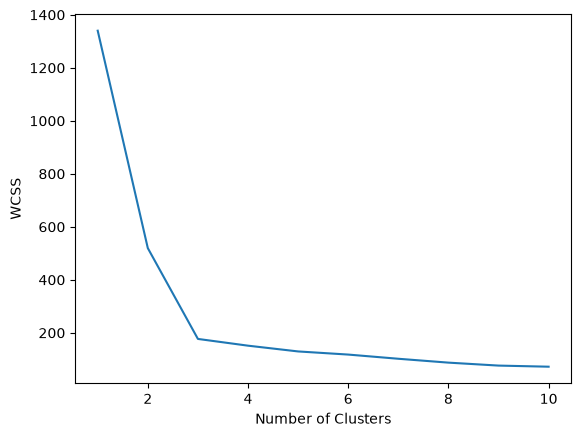

In [9]:
plt.plot(wcss.keys(), wcss.values())
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [10]:
# From the elbow method, we can see that the optimal number of clusters is 3. Let's fit the KMeans model with k=3.

kmeans = KMeans(n_clusters=3, init="k-means++")

In [11]:
kmeans.fit_predict(X_train_scaled)

array([0, 1, 1, 2, 1, 1, 2, 1, 2, 0, 1, 0, 2, 1, 2, 1, 0, 1, 2, 1, 1, 1,
       2, 2, 1, 1, 0, 0, 0, 2, 2, 0, 1, 2, 1, 1, 0, 1, 1, 2, 0, 1, 2, 1,
       1, 2, 0, 2, 1, 0, 0, 2, 2, 0, 2, 0, 1, 2, 0, 2, 2, 2, 0, 0, 2, 0,
       0, 0, 0, 1, 2, 1, 1, 1, 0, 0, 0, 2, 0, 1, 2, 2, 2, 0, 0, 1, 1, 2,
       0, 0, 2, 2, 0, 1, 0, 0, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 1, 1, 2, 1, 0, 0, 2, 1, 0, 1, 1, 0,
       0, 2, 2, 1, 2, 0, 1, 0, 0, 2, 0, 1, 0, 1, 2, 2, 1, 2, 2, 1, 2, 2,
       0, 2, 2, 2, 1, 1, 2, 0, 0, 2, 1, 1, 2, 1, 1, 2, 2, 2, 0, 0, 2, 0,
       2, 0, 2, 1, 0, 0, 0, 2, 2, 2, 1, 0, 0, 1, 0, 2, 0, 2, 2, 1, 2, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 2, 1, 2, 1, 1, 2, 0, 2, 0, 0, 2, 1, 0, 2,
       0, 0, 1, 0, 2, 0, 1, 0, 2, 0, 0, 2, 1, 2, 2, 0, 2, 2, 0, 1, 0, 0,
       1, 2, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 2, 0, 2, 0, 2, 2,
       1, 0, 0, 0, 2, 1, 2, 2, 1, 2, 2, 0, 0, 2, 0, 0, 2, 1, 2, 0, 0, 0,
       0, 1, 0, 2, 2, 1, 2, 1, 2, 1, 0, 2, 2, 0, 2,

In [12]:
y_pred = kmeans.predict(X_test_scaled)

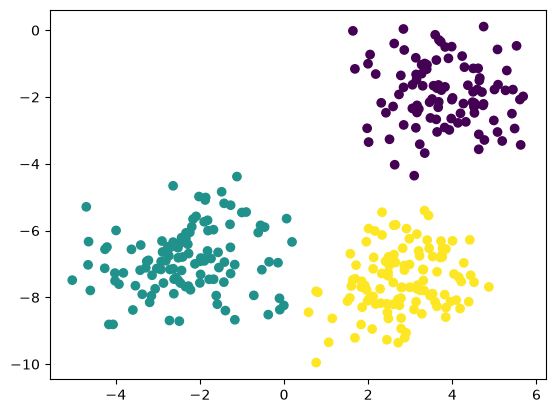

In [13]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)

In [14]:
# Validating the k value
# 1) Kneelocator
!pip install kneed
# 2) Silhoutee scoring


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# KneeLocator
from kneed import KneeLocator

kl = KneeLocator(list(wcss.keys()), list(wcss.values()), curve="convex", direction="decreasing")

In [16]:
kl.elbow

np.int64(3)

In [17]:
# Silhoute score
from sklearn.metrics import silhouette_score

silhouette_coefs = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefs.update({k: score})

In [18]:
silhouette_coefs

{2: 0.5668140700421271,
 3: 0.6497858484977957,
 4: 0.5316370241480284,
 5: 0.416584907094089,
 6: 0.33483991637802196,
 7: 0.3362418660401238,
 8: 0.3174958589703759,
 9: 0.33498833336332035,
 10: 0.3339076422521932}

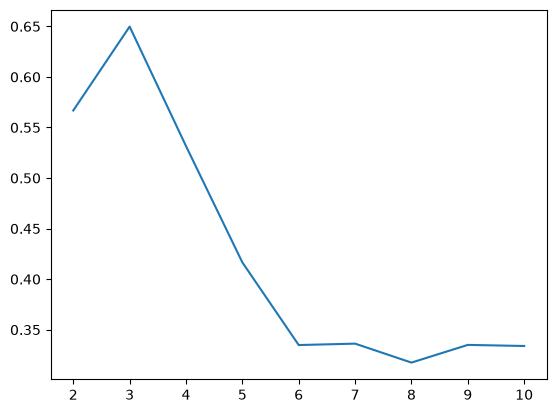

In [19]:
plt.plot(list(silhouette_coefs.keys()),list(silhouette_coefs.values()))